# Анализ датасета google books.

## Подготовительный процесс

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv("../data/google_books_dataset.csv")

## Первичный обзор данных

In [35]:
df.head()

,book_id,title,subtitle,authors,publisher,published_date,description,page_count,categories,average_rating,...,language,preview_link,info_link,isbn_13,isbn_10,list_price,currency,buyable,search_category,thumbnail
0,LR_VDQAAQBAJ,Bestsellers,"The Path (bestsellers, free bestsellers, bests...","Ivan King, bestsellers",bestsellers,2017-01-04,"Hear What the Critics are Saying ""Wow, what an...",70.0,Young Adult Fiction,NaN,...,en,http://books.google.com/books?id=LR_VDQAAQBAJ&...,https://play.google.com/store/books/details?id...,NaN,NaN,12.99,USD,True,fiction bestsellers,http://books.google.com/books/content?id=LR_VD...
1,WcjTDQAAQBAJ,Bestsellers,"Hell: A Place Without Hope (bestseller books, ...","Ivan King, bestsellers",bestsellers,2017-01-03,"Hear What the Critics are Saying Wow, very ins...",32.0,Comics & Graphic Novels,NaN,...,en,http://books.google.com/books?id=WcjTDQAAQBAJ&...,https://play.google.com/store/books/details?id...,NaN,NaN,9.99,USD,True,fiction bestsellers,http://books.google.com/books/content?id=WcjTD...
2,4fXUDAAAQBAJ,The Bestseller Code,Anatomy of the Blockbuster Novel,"Jodie Archer, Matthew L. Jockers",Macmillan,2016-09-20,"""What if there was an algorithm that could pre...",253.0,Business & Economics,NaN,...,en,http://books.google.com/books?id=4fXUDAAAQBAJ&...,http://books.google.com/books?id=4fXUDAAAQBAJ&...,9.781250e+12,1250088275,NaN,NaN,False,fiction bestsellers,http://books.google.com/books/content?id=4fXUD...
3,yIVuDwAAQBAJ,Bestseller,A Century of America's Favorite Books,Robert McParland,Bloomsbury Publishing PLC,2018-12-15,Whether curled up on a sofa with a good myster...,335.0,Literary Criticism,NaN,...,en,http://books.google.com/books?id=yIVuDwAAQBAJ&...,https://play.google.com/store/books/details?id...,9.781538e+12,1538110008,40.50,USD,True,fiction bestsellers,http://books.google.com/books/content?id=yIVuD...
4,2JHXwAEACAAJ,Bestsellers: Popular Fiction since 1900,NaN,C. Bloom,Palgrave Macmillan,2002-07-09,This guide and reference work of all of the be...,306.0,Literary Criticism,NaN,...,en,http://books.google.com/books?id=2JHXwAEACAAJ&...,http://books.google.com/books?id=2JHXwAEACAAJ&...,9.780334e+12,0333687426,NaN,NaN,False,fiction bestsellers,http://books.google.com/books/content?id=2JHXw...


In [36]:
df.tail()

,book_id,title,subtitle,authors,publisher,published_date,description,page_count,categories,average_rating,...,language,preview_link,info_link,isbn_13,isbn_10,list_price,currency,buyable,search_category,thumbnail
15142,xeEdAQAAMAAJ,DIY Retailing,NaN,NaN,NaN,1985,NaN,1056.0,Building materials,NaN,...,en,http://books.google.com/books?id=xeEdAQAAMAAJ&...,http://books.google.com/books?id=xeEdAQAAMAAJ&...,NaN,NaN,NaN,NaN,False,language_English,http://books.google.com/books/content?id=xeEdA...
15143,-gG1i0B9EQ0C,Masquerade Evil Dual,NaN,Suzwalt Lapoint,Ace Books,1980-12,NaN,420.0,NaN,NaN,...,en,http://books.google.com/books?id=-gG1i0B9EQ0C&...,http://books.google.com/books?id=-gG1i0B9EQ0C&...,9.780442e+12,044152091X,NaN,NaN,False,language_English,http://books.google.com/books/content?id=-gG1i...
15144,-Rdwn1PytagC,Indiana Slavic Studies,NaN,NaN,NaN,2000,NaN,444.0,Slavic countries,NaN,...,en,http://books.google.com/books?id=-Rdwn1PytagC&...,http://books.google.com/books?id=-Rdwn1PytagC&...,NaN,NaN,NaN,NaN,False,language_English,http://books.google.com/books/content?id=-Rdwn...
15145,_3vfMAwwezwC,The Literary Digest,NaN,"Edward Jewitt Wheeler, Isaac Kaufman Funk, Wil...",NaN,1918,NaN,1068.0,Literature,NaN,...,en,http://books.google.com/books?id=_3vfMAwwezwC&...,https://play.google.com/store/books/details?id...,NaN,NaN,NaN,NaN,False,language_English,http://books.google.com/books/content?id=_3vfM...
15146,yqWlwa0S5twC,Furniture Index,NaN,NaN,NaN,1924,NaN,1012.0,Furniture industry and trade,NaN,...,en,http://books.google.com/books?id=yqWlwa0S5twC&...,https://play.google.com/store/books/details?id...,NaN,NaN,NaN,NaN,False,language_English,http://books.google.com/books/content?id=yqWlw...


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15147 entries, 0 to 15146
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   book_id          15147 non-null  str    
 1   title            15139 non-null  str    
 2   subtitle         5983 non-null   str    
 3   authors          11622 non-null  str    
 4   publisher        7090 non-null   str    
 5   published_date   14933 non-null  str    
 6   description      8351 non-null   str    
 7   page_count       14933 non-null  float64
 8   categories       12695 non-null  str    
 9   average_rating   857 non-null    float64
 10  ratings_count    15147 non-null  int64  
 11  language         15147 non-null  str    
 12  preview_link     15147 non-null  str    
 13  info_link        15147 non-null  str    
 14  isbn_13          7383 non-null   float64
 15  isbn_10          7121 non-null   str    
 16  list_price       2943 non-null   float64
 17  currency         2943 n

### Вывод
Первичный обзор проведен и данные изучены. Типы данных проверены. Нет необходимости их корректировать.

In [38]:
df.dtypes

book_id                str
title                  str
subtitle               str
authors                str
publisher              str
published_date         str
description            str
page_count         float64
categories             str
average_rating     float64
ratings_count        int64
language               str
preview_link           str
info_link              str
isbn_13            float64
isbn_10                str
list_price         float64
currency               str
buyable               bool
search_category        str
thumbnail              str
dtype: object

# Обработка данных.

## Пропущенные значения.

In [39]:
df.isnull().sum() # получаем кол-во непустых строк в каждом столбце

book_id                0
title                  8
subtitle            9164
authors             3525
publisher           8057
published_date       214
description         6796
page_count           214
categories          2452
average_rating     14290
ratings_count          0
language               0
preview_link           0
info_link              0
isbn_13             7764
isbn_10             8026
list_price         12204
currency           12204
buyable                0
search_category        0
thumbnail            669
dtype: int64

### Вывод 
После анализа кол-ва пропусков было принято решение не изменять пропущенные значения, так как это могло бы привести к искажению результата анализа данных.

Основные причины:
- отсутствие цены означает, что книга не продается через Google Books;
- отсутствие валюты связано с отсутствием цены;
- отсутствие подзаголовка является нормальной особенностью многих книг;
- отсутствие рейтинга означает, что книга еще не получила пользовательских оценок.

## Дубликаты.

In [40]:
df.duplicated().sum() # проверяем на наличие дубликатов

np.int64(0)

### Вывод
После проверки дубликатов было установлено, что совпадащие строки отсутсвуют в датасете. Следовательно, удаление не требуется.

## Анализ выбросов

In [41]:
from scipy.stats import zscore

page_count = df['page_count'].dropna() #убираем пропуски, чтобы не было ошибок при рассчете zscore

zc = zscore(page_count)
(np.abs(zc) > 3).sum() #отобрали возможные выбросы

np.int64(230)

<Axes: >

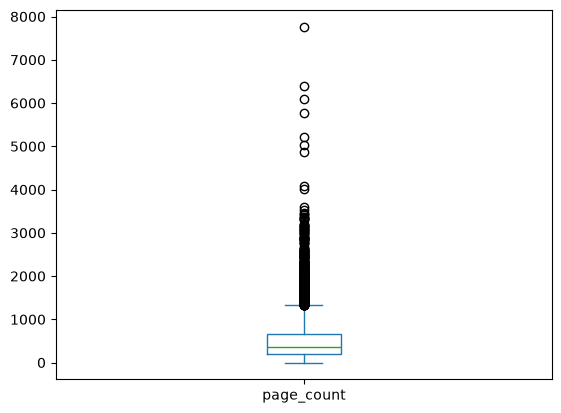

In [42]:
df['page_count'].plot.box() #рисуем график boxplot для анализа выьросов

### Вывод
 После проведения анализа выьросов с помощью метода z-score и boxplot было принято решение, что такие значения могут соотвествовать реальным энциклопедиям, справочникам и многотомным изданиям. Следовательно, выбросы не удалялись.

## Статистики данных.

In [43]:
df.describe() #выводим основные статист-е показетели

,page_count,average_rating,ratings_count,isbn_13,list_price
count,14933.000000,857.000000,15147.000000,7.383000e+03,2943.000000
mean,484.793277,4.046091,0.379349,9.782399e+12,48.167550
std,438.477177,1.105387,9.274538,3.730871e+09,81.431226
min,0.000000,1.000000,0.000000,9.780002e+12,0.000000
25%,205.000000,3.500000,0.000000,9.780763e+12,9.975000
50%,368.000000,4.000000,0.000000,9.781430e+12,19.000000
75%,658.000000,5.000000,0.000000,9.781787e+12,58.000000
max,7768.000000,5.000000,826.000000,9.798999e+12,1755.000000


In [44]:
df.nunique() #подсчитываем кол-во уник-ых значений

book_id            15147
title              13144
subtitle            5281
authors             9025
publisher           2001
published_date      4144
description         7980
page_count          1496
categories          1829
average_rating         9
ratings_count         50
language              37
preview_link       15147
info_link          15147
isbn_13             7377
isbn_10             7115
list_price           690
currency               1
buyable                2
search_category      149
thumbnail          14478
dtype: int64

In [45]:
df["language"].value_counts() #подсчитываем кол-во уник-ых значений в столбце language

language
en       14821
es          69
de          42
fr          35
pt-BR       34
it          22
zh-CN       18
nl          12
id           9
da           8
tr           8
ko           6
ro           6
cs           6
pl           6
vi           5
fi           5
ca           5
hi           4
hu           4
mr           3
ru           2
ta           2
iw           2
ja           1
ga           1
el           1
fy           1
fa           1
mn           1
sl           1
ar           1
te           1
gu           1
et           1
ts           1
bs           1
Name: count, dtype: int64

In [46]:
df["average_rating"].value_counts().sort_index() #делаем частотный анализ рейтингов 
                                                 #и сортируем по индексу

average_rating
1.0     39
1.5      1
2.0     52
2.5      7
3.0     88
3.5     48
4.0    199
4.5     75
5.0    348
Name: count, dtype: int64

In [47]:
df.corr(numeric_only=True) #вычисляем корреляцию между числовыми столбцами

,page_count,average_rating,ratings_count,isbn_13,list_price,buyable
page_count,1.000000,-0.025516,0.001393,-0.086095,0.430509,-0.129896
average_rating,-0.025516,1.000000,-0.034176,0.014513,-0.025649,0.015155
ratings_count,0.001393,-0.034176,1.000000,-0.022802,-0.029360,0.047068
isbn_13,-0.086095,0.014513,-0.022802,1.000000,0.055735,-0.012905
list_price,0.430509,-0.025649,-0.029360,0.055735,1.000000,-0.243686
buyable,-0.129896,0.015155,0.047068,-0.012905,-0.243686,1.000000


### Вывод

После анализа описательной статистики установлено, что ср-ее кол-во старниц книги составляет около 485, а ср-яя цена книг - около 48(для книг, у которых указана цена). Максимальное число страниц достигает 7768, а макс-ая цена - 1755. Минимальная цена равна 0, что может свидетельствовать о наличии бесплатных книг. Также выявлено, что большинство книг(не менее 75%) не получили пользовательских оценок.

После подсчета уник-ых значений выявлено, что большинство книг написаны на английском языке(около 98%). Много различных авторов книг и изданий. Большинсвто оцененных книг имеют высокие рейтинги(~72% оцененных книг, имеют рейтинг от 4 до 5). Наиболее распространенная оценка - 5(~37%).

После корреляционного анализа выявлена положительная зависимость между кол-вом страниц и ценой(0.43). Остальные показатели были незначительными.
